In [1]:
# region Imports

#* --------------------------------------------------------------------------------
#* General purpose imports
#* --------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import fisher_exact, barnard_exact, ranksums
from matplotlib.ticker import FuncFormatter
import pickle as pkl


#* --------------------------------------------------------------------------------
#* Personal librairies imports
#* --------------------------------------------------------------------------------
import sys, os
src_path = os.path.abspath(os.path.join("..", "src"))
if src_path not in sys.path:
    sys.path.insert(0, src_path)
from utils import astro_utils as au
from utils import maths_utils  as mu
from utils import stats_utils  as su
from utils import graphics_utils  as gu
from utils import labels_utils  as lu
from utils import pandas_utils  as pu


#* --------------------------------------------------------------------------------
#* Project modules imports
#* --------------------------------------------------------------------------------
import sSFR
import generate_report as report
import domination

#* --------------------------------------------------------------------------------
#* Global variables
#* --------------------------------------------------------------------------------
import config as co

#* --------------------------------------------------------------------------------
#* Project data
#* --------------------------------------------------------------------------------

with open(co.DATA_PATH + co.PROCESS_SAMPLES, "rb") as file:
            sample = pkl.load(file)



# endregion

Done


/var/folders/2l/5qdg19zx40sdthfzpld2xpq80000gn/T/ipykernel_70442/4008767043.py:205: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/var/folders/2l/5qdg19zx40sdthfzpld2xpq80000gn/T/ipykernel_70442/4008767043.py:205: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


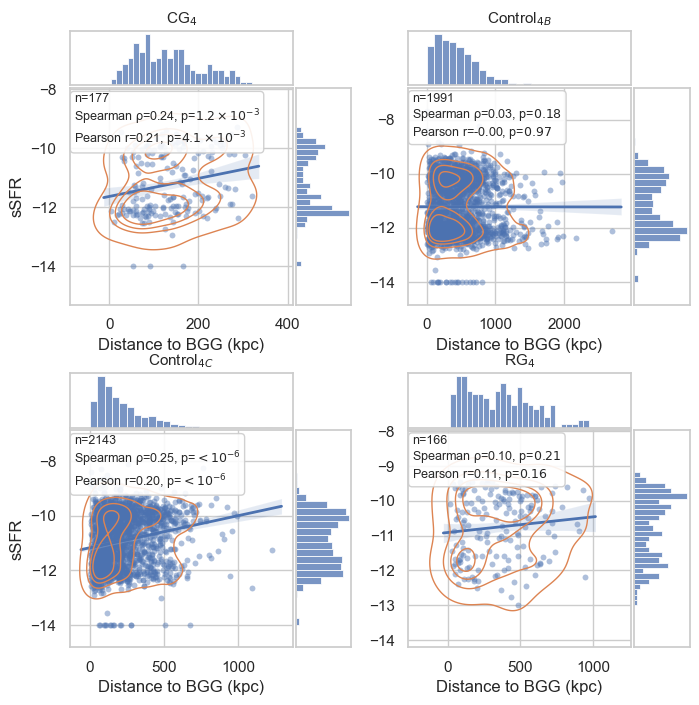

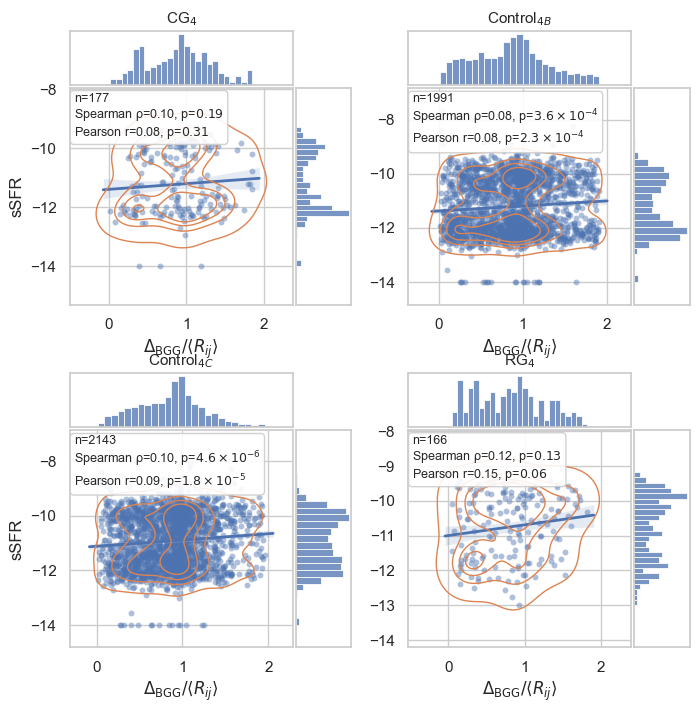

In [2]:
# ============================================================
# Two multi-panel "jointplot-like" figures:
#   (1) sSFR vs projected distance to BGG in kpc
#   (2) sSFR vs normalized distance:
#         - Control4C:  Δ_BGG / <R_ij>  using size_Group_Bary_kpc
#         - others:     Δ_BGG / R200    using r_200_kpc
#
# IMPORTANT legacy fix:
#   Your old dist2BGG code returned: dist2BGG = theta_rad * 3600
#   so theta_rad = dist2BGG / 3600.
# ============================================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr, pearsonr
import astropy.units as u
from astropy.cosmology import Planck15  # Planck Collaboration XIII (2016) ~ Planck 2015 cosmology


# -----------------------------
# Compute projected distance (kpc) from legacy dist2BGG
# -----------------------------
def add_dist2BGG_kpc_legacy(
    gdf: pd.DataFrame,
    group_col: str = "Group",
    z_col: str = "z",
    dist_ang_col: str = "dist2BGG",
    out_kpc_col: str = "dist2BGG_kpc",
    z_agg: str = "median",
) -> pd.DataFrame:
    """
    Legacy dist2BGG definition:
        dist2BGG = theta_rad * 3600
    so:
        theta_rad = dist2BGG / 3600

    Projected separation:
        Rproj_kpc = theta * D_A(z_group)
    computed using kpc_proper_per_arcmin (Planck15) and theta in arcmin.
    """
    if z_agg not in {"median", "mean"}:
        raise ValueError("z_agg must be 'median' or 'mean'.")

    df = gdf.copy()
    df[dist_ang_col] = pd.to_numeric(df[dist_ang_col], errors="coerce")
    df[z_col] = pd.to_numeric(df[z_col], errors="coerce")

    if z_agg == "median":
        z_group = df.groupby(group_col)[z_col].transform("median")
    else:
        z_group = df.groupby(group_col)[z_col].transform("mean")

    # kpc per arcmin at each z
    kpc_per_arcmin = Planck15.kpc_proper_per_arcmin(z_group.to_numpy())

    # convert legacy stored value -> radians -> arcmin
    theta_rad = df[dist_ang_col].to_numpy() / 3600.0
    theta_arcmin = (theta_rad * u.rad).to(u.arcmin).value

    df[out_kpc_col] = theta_arcmin * kpc_per_arcmin.to(u.kpc / u.arcmin).value
    return df


# -----------------------------
# Subplot-friendly "jointplot"
# -----------------------------
def _mini_joint(
    fig,
    outer_spec,
    df,
    x,
    y="sSFR",
    title="",
    x_label="",
    y_label="sSFR",
    add_kde=True,
    add_reg=True,
    ci=95,
    bins=25,
    show_ylabel=True,
    inner_hspace=0.02,
    inner_wspace=0.02,
):
    gs = outer_spec.subgridspec(
        2, 2,
        height_ratios=(1, 4),
        width_ratios=(4, 1),
        hspace=inner_hspace,
        wspace=inner_wspace,
    )
    ax_top   = fig.add_subplot(gs[0, 0])
    ax_joint = fig.add_subplot(gs[1, 0])
    ax_right = fig.add_subplot(gs[1, 1])

    # numeric clean
    d = df[[x, y]].copy()
    d[x] = pd.to_numeric(d[x], errors="coerce")
    d[y] = pd.to_numeric(d[y], errors="coerce")
    d = d.replace([np.inf, -np.inf], np.nan).dropna()
    n = len(d)

    sns.scatterplot(data=d, x=x, y=y, ax=ax_joint, s=18, alpha=0.45, linewidth=0)

    if add_reg and n >= 3:
        sns.regplot(
            data=d, x=x, y=y, ax=ax_joint,
            scatter=False, ci=ci, n_boot=1000,
            truncate=False, line_kws=dict(linewidth=2)
        )

    if add_kde and n >= 20:
        sns.kdeplot(data=d, x=x, y=y, ax=ax_joint, levels=5, fill=False, linewidths=1)

    sns.histplot(data=d, x=x, ax=ax_top, bins=bins, kde=False)
    sns.histplot(data=d, y=y, ax=ax_right, bins=bins, kde=False)

    # no ticks on marginals
    ax_top.set_xticks([]); ax_top.set_yticks([])
    ax_right.set_xticks([]); ax_right.set_yticks([])
    ax_top.set_xlabel(""); ax_top.set_ylabel("")
    ax_right.set_xlabel(""); ax_right.set_ylabel("")

    ax_top.set_xlim(ax_joint.get_xlim())
    ax_right.set_ylim(ax_joint.get_ylim())

    ax_joint.set_xlabel(x_label)                 # x-label on every panel (requested)
    ax_joint.set_ylabel(y_label if show_ylabel else "")

    # stats with your formatter
    if n >= 3:
        rho_s, p_s = spearmanr(d[x], d[y])
        r_p, p_p   = pearsonr(d[x], d[y])
        txt = (
            f"n={n}\n"
            f"Spearman ρ={rho_s:.2f}, p={gu.tex_form(p_s)}\n"
            f"Pearson r={r_p:.2f}, p={gu.tex_form(p_p)}"
        )
    else:
        txt = f"n={n}\n(not enough data)"

    ax_joint.text(
        0.02, 0.98, txt,
        transform=ax_joint.transAxes,
        ha="left", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.8", alpha=0.9),
    )

    if title:
        ax_top.set_title(title, fontsize=11)

    return ax_joint


# -----------------------------
# Build a near-square multi-panel figure
# -----------------------------
def _make_grid_figure(panels, y="sSFR", figsize_per_panel=4.0,
                      outer_wspace=0.20, outer_hspace=0.25,
                      inner_hspace=0.02, inner_wspace=0.02):
    """
    panels: list of tuples (cat, df, xcol, xlabel)
    """
    sns.set_theme(style="whitegrid", context="notebook")

    n_panels = len(panels)
    if n_panels == 0:
        raise ValueError("No panels to plot.")

    ncols = math.ceil(math.sqrt(n_panels))
    nrows = math.ceil(n_panels / ncols)

    fig = plt.figure(figsize=(figsize_per_panel * ncols, figsize_per_panel * nrows))
    outer = fig.add_gridspec(nrows, ncols, wspace=outer_wspace, hspace=outer_hspace)

    for i, (cat, df, xcol, xlabel) in enumerate(panels):
        r = i // ncols
        c = i % ncols
        show_ylabel = (c == 0)

        _mini_joint(
            fig,
            outer[r, c],
            df,
            x=xcol,
            y=y,
            title=lu.formatted_sample_name(cat),
            x_label=xlabel,
            y_label=y,
            show_ylabel=show_ylabel,
            inner_hspace=inner_hspace,
            inner_wspace=inner_wspace,
        )

    # hide unused cells
    for j in range(n_panels, nrows * ncols):
        r = j // ncols
        c = j % ncols
        ax = fig.add_subplot(outer[r, c])
        ax.axis("off")

    fig.tight_layout()
    return fig


# ============================================================
# MAIN: compute columns + produce the 2 figures
# ============================================================
def make_two_figures(
    sample,
    co,
    # columns
    group_col="Group",
    z_col="z",
    dist_ang_col="dist2BGG",
    y_col="sSFR",
    rank_cut=1,
    # normalization columns in group DFs
    # r200_col="r_200_kpc",
    r200_col="size_Group_Bary_kpc",
    control4c_norm_col="size_Group_Bary_kpc",
    # plotting
    figsize_per_panel=4.0,
):
    """
    Returns (fig_kpc, fig_norm).
    Also writes back dist2BGG_kpc (and norm_dist) into each galaxy DF in sample.
    """

    panels_kpc = []
    panels_norm = []

    for cat in co.SAMPLE.keys():
        gal_key = cat + co.GASUFF
        grp_key = cat + co.GRSUFF

        if gal_key not in sample or grp_key not in sample:
            continue

        gdf = sample[gal_key].copy()
        rdf = sample[grp_key].copy()

        # Required columns for kpc computation
        req_g = [group_col, z_col, dist_ang_col, "rank_M", y_col]
        missing_g = [c for c in req_g if c not in gdf.columns]
        if missing_g:
            raise KeyError(f"{gal_key} missing columns: {missing_g}")

        # 1) compute dist2BGG_kpc (legacy fix included)
        gdf = add_dist2BGG_kpc_legacy(
            gdf,
            group_col=group_col,
            z_col=z_col,
            dist_ang_col=dist_ang_col,
            out_kpc_col="dist2BGG_kpc",
            z_agg="median",
        )

        # satellites only
        gdf_sat = gdf.loc[gdf["rank_M"] > rank_cut].copy()

        # Panel for kpc figure
        panels_kpc.append((
            cat,
            gdf_sat,
            "dist2BGG_kpc",
            "Distance to BGG (kpc)"
        ))

        # 2) normalized distance (sample-dependent)
        if cat == "Control4C":
            norm_col = control4c_norm_col
            xlabel_norm = r"$\Delta_{\mathrm{BGG}}/\langle R_{ij}\rangle$"
        else:
            # norm_col = r200_col
            # xlabel_norm = r"$\Delta_{\mathrm{BGG}}/R_{200}$"
            norm_col = control4c_norm_col
            xlabel_norm = r"$\Delta_{\mathrm{BGG}}/\langle R_{ij}\rangle$"

        if group_col not in rdf.columns or norm_col not in rdf.columns:
            raise KeyError(f"{grp_key} must contain '{group_col}' and '{norm_col}'")

        rdf_min = rdf[[group_col, norm_col]].copy()
        rdf_min[norm_col] = pd.to_numeric(rdf_min[norm_col], errors="coerce")
        rdf_min = rdf_min.groupby(group_col, as_index=False)[norm_col].median()

        gdf = gdf.merge(rdf_min, on=group_col, how="left", validate="m:1")

        gdf["norm_dist"] = pd.to_numeric(gdf["dist2BGG_kpc"], errors="coerce") / pd.to_numeric(gdf[norm_col], errors="coerce")

        # satellites for normalized
        gdf_sat2 = gdf.loc[gdf["rank_M"] > rank_cut].copy()

        panels_norm.append((
            cat,
            gdf_sat2,
            "norm_dist",
            xlabel_norm
        ))

        # write back enriched galaxy df (optional but handy)
        sample[gal_key] = gdf

    # produce the figures
    fig_kpc = _make_grid_figure(
        panels_kpc,
        y=y_col,
        figsize_per_panel=figsize_per_panel,
    )
    fig_norm = _make_grid_figure(
        panels_norm,
        y=y_col,
        figsize_per_panel=figsize_per_panel,
    )

    return fig_kpc, fig_norm


# -----------------------------
# USAGE
# -----------------------------
fig_kpc, fig_norm = make_two_figures(sample, co, rank_cut=1, figsize_per_panel=4.0)
fig_kpc.savefig(co.FIGURES_PATH + "dist2BGG_kpc_vs_sSFR.pdf", dpi=300, bbox_inches="tight")
fig_norm.savefig(co.FIGURES_PATH + "dist2BGG_norm_vs_sSFR.pdf", dpi=300, bbox_inches="tight")
plt.show()